# Citation
Sravan Pannala et al "Consistently Tuned Battery Lifetime Predictive Model of Capacity Loss, Resistance Increase, and Irreversible Thickness Growth" J. Electrochem. Soc. 171 010532 (2024)  
Section: Degradation Model Tuning Process

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)

eSOH_DIR = "./data/"
oCV_DIR = "./data/"

In [2]:
# get parameter values
parameter_values = get_parameter_values()
# define model
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
#model internal parameters
param=spm.param

In [3]:
# Define pulse (step input) to estimate resistance V
t_in0 = 1
t_in1 = 1
t_inf = t_in0+t_in1
t_in = np.arange(0,t_inf,0.1)
I_in = []
for tt in t_in:
    if tt<t_in0:
        I_in = np.append(I_in,0)
    elif tt>=t_in0 and tt<t_in0+t_in1:
        I_in = np.append(I_in,5)

# get resistance at a particular SOC
def get_pulse_res(parameter_values,esoh_sol,SOC):
    """
    get resistance at a particular SOC

    Args:
        parameter_values : dictionary of parameter values
        esoh_sol : eSOH ouputs from eSOH model ouput at a particular RPT
        SOC : SOC to evaluate resistance at

    Returns:
        resistance
    """    
    c_n_max = parameter_values.evaluate(param.n.prim.c_max)
    c_p_max = parameter_values.evaluate(param.p.prim.c_max)
    x_100 = esoh_sol["x_100"].data[0]
    y_100 = esoh_sol["y_100"].data[0]
    x_0 = esoh_sol["x_0"].data[0]
    y_0 = esoh_sol["y_0"].data[0]
    # get initial concentration of the two electrodes at a particular SOC
    cs_n_0 = (SOC*(x_100-x_0)+x_0)*c_n_max
    cs_p_0 = (SOC*(y_100-y_0)+y_0)*c_p_max
    # update initial concentration 
    parameter_values.update(
      {
          "Initial concentration in negative electrode [mol.m-3]": cs_n_0,
          "Initial concentration in positive electrode [mol.m-3]": cs_p_0,        
      }
    )
    # simulate pulse
    sim_pulse = pybamm.Simulation(spm, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver(mode="safe", rtol=1e-6, atol=1e-6,dt_max=0.1))
    # solve pulse simulation
    sol_pulse = sim_pulse.solve(t_eval=t_in)
    I   =  sol_pulse["Current [A]"].entries
    Vt  =  sol_pulse["Terminal voltage [V]"].entries
    # find points before and after pulse
    idx = np.where(np.diff(np.sign(-I)))[0]
    # resistance = delta V/ delta I
    Rs = abs((Vt[idx+1]-Vt[idx])/(I[idx+1]-I[idx]))[0]
    return Rs

# function to get resistance at various SOC points
def get_Rs(cyc_no,eSOH,parameter_values,Ns):
  """
  get R at various SOC points at a particular cycle number
  Args:
      cyc_no : cycle number to evaluate the resistance 
      eSOH : eSOH parameters of the model at a particular cycle number
      parameter_values : dictionary of parameter cycles
      Ns : vector of cycle numbers for all RPTs 

  Returns:
      vector of resistance values at various SOCs
  """  
  model = spm
  Vmin = 3.0
  Vmax = 4.2
  # define eSOH model
  esoh_model = pybamm.lithium_ion.ElectrodeSOH()
  esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
  # initial Cn and Cp values from the aging simulations
  Cn = eSOH["C_n"][Ns[cyc_no]]
  Cp = eSOH["C_p"][Ns[cyc_no]]
  c_n_max = parameter_values.evaluate(param.n.prim.c_max)
  c_p_max = parameter_values.evaluate(param.p.prim.c_max)
  n_Li_init = eSOH["Total lithium in particles [mol]"][Ns[cyc_no]]
  c_plated_Li = eSOH['X-averaged lithium plating concentration [mol.m-3]'][Ns[cyc_no]]
  eps_n_data = parameter_values.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
  eps_p_data = parameter_values.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
  del_sei = eSOH['X-averaged SEI thickness [m]'][Ns[cyc_no]]
  # Run eSOH model to find stoichiometric windows at a particular cycle
  esoh_sol = esoh_sim.solve(
      [0],
      inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
      solver=pybamm.AlgebraicSolver(),
  )
  # update active material ratios, SEI thickness and plated lithium concentration
  parameter_values.update(
          {
              "Negative electrode active material volume fraction": eps_n_data,
              "Positive electrode active material volume fraction": eps_p_data,
              "Initial inner SEI thickness [m]": 0e-09,
              "Initial outer SEI thickness [m]": del_sei,
              "Initial plated lithium concentration [mol.m-3]": c_plated_Li,
          }
        )
  # get charge resistance
  timescale = parameter_values.evaluate(spm.timescale)
  # define pulse current
  current_interpolant = pybamm.Interpolant(
    t_in, -I_in, timescale * pybamm.t
  )
  parameter_values["Current function [A]"] = current_interpolant
  SOC_vals = np.linspace(1,0,11)
  Rs_ch_s = []
  # get resistance at multiple SOCs
  for SOC in SOC_vals[1:10]:
      Rs_t = get_pulse_res(parameter_values,esoh_sol,SOC)
      Rs_ch_s.append(Rs_t)
  Rs_ch = np.average(Rs_ch_s)
  # get discharge resistance  
  current_interpolant = pybamm.Interpolant(
    t_in, I_in, timescale * pybamm.t
  )
  parameter_values["Current function [A]"] = current_interpolant
  SOC_vals = np.linspace(1,0,11)
  Rs_dh_s = []
  for SOC in SOC_vals[1:10]:
      Rs_t = get_pulse_res(parameter_values,esoh_sol,SOC)
      Rs_dh_s.append(Rs_t)
  Rs_dh = np.average(Rs_dh_s)
  Rs = (Rs_dh + Rs_ch)/2
  return Rs

CasADi - 2024-03-18 14:18:00 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


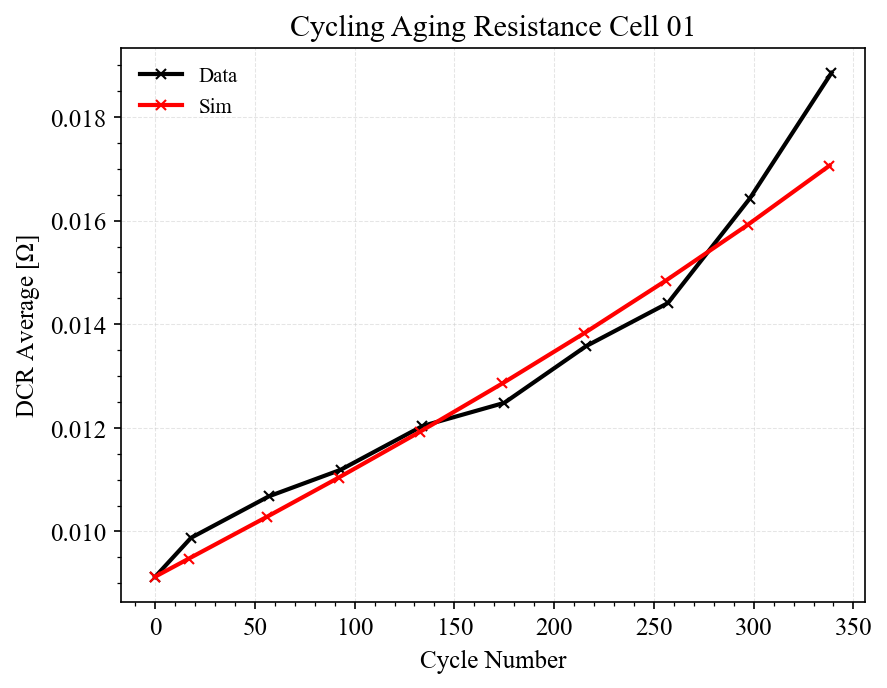

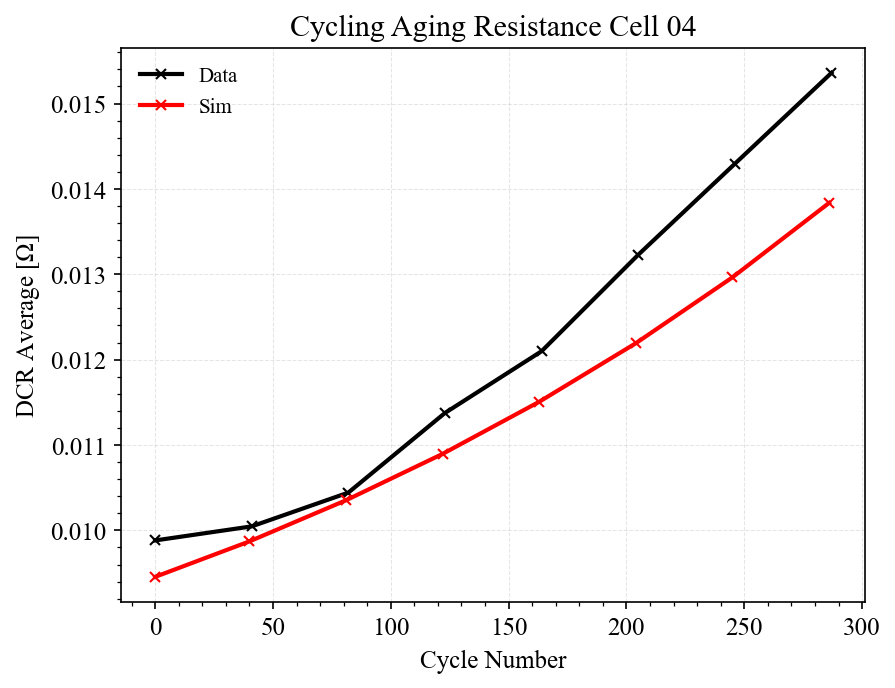

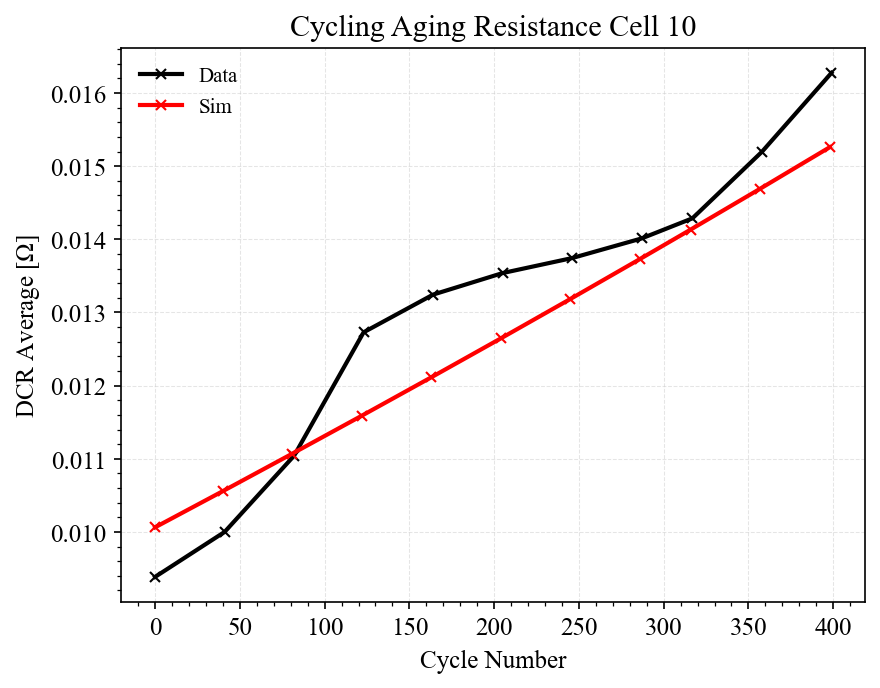

In [4]:
cells = [1,4,10]
for cell in cells:
    # load the data for each cell
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    Ns = np.insert(N[1:]-1,0,0)
    # get parameters to intialize the model
    eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
    experiment = pybamm.Experiment(
        [
            ("Discharge at "+c_rate_d+dis_set,
            "Rest for 10 sec",
            "Charge at "+c_rate_c+" until 4.2V", 
            "Hold at 4.2V until C/100")
        ] *dfe.N.iloc[-1],
        # ] *40,
        termination="50% capacity",
    #     cccv_handling="ode",
    )
    # simulate the model
    parameter_values.update(
        {
            "Positive electrode LAM constant proportional term [s-1]": 3.6297e-08,
            "Negative electrode LAM constant proportional term [s-1]": 1.8566e-07,
            "Positive electrode LAM constant exponential term": 1.0921,
            "Negative electrode LAM constant exponential term": 1.0921,
            "Lithium plating kinetic rate constant [m.s-1]": 2.1484e-09,
            "Positive electrode LAM constant proportional term 2 [s-1]": -3.5501e-09,
            "Negative electrode LAM constant proportional term 2 [s-1]": -5.2027e-09,
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            "SEI kinetic rate constant [m.s-1]": 5.8561e-16,
            "EC diffusivity [m2.s-1]": 2.4779e-19,
            "SEI growth activation energy [J.mol-1]": 19669.2,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        },
        check_already_exists=False,
    )
    # change the resistivity values manually to get different values of resistance
    # manual tuning used to get the values of resistivity reported in the paper
    # equation 56 in paper
    parameter_values.update(
        {
            "Li plating resistivity [Ohm.m]": 30000.0,
            "SEI resistivity [Ohm.m]": 30000.0,
        },
        check_already_exists=False,
    )
    # simulate lifetime aging
    all_sumvars_dict = cycle_adaptive_simulation_V2(spm, parameter_values, experiment,SOC_0, save_at_cycles=1)
    Rs = []
    # get resistance at different RPT points
    for cyc_no in range(len(Ns)):
        Rs_t = get_Rs(cyc_no,all_sumvars_dict,parameter_values,Ns)
        Rs.append(Rs_t)
    # save resistance to a dataframe
    df = pd.DataFrame({'N': N,'Ah_th':dfe["Ah_th"]-dfe["Ah_th"][0], 'Rs_data': dfe["Rs_ave"],'Rs_sim':Rs,
                    })
    # Plot DC average resistance of model vs data across life
    fig, ax = plt.subplots(1,1)
    ax.plot(dfe["N"],dfe["Rs_ave"],'kx-')
    ax.plot(Ns,Rs,'rx-')
    ax.set_xlabel('Cycle Number')
    ax.set_ylabel(r'DCR Average [$\Omega$]')
    ax.legend(['Data','Sim'])
    ax.set_title(f"Cycling Aging Resistance Cell {cell_no}")